In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("data/ab_experiment_data.csv")

# clean
df = df[df["test_group"].isin(["ad", "psa"])].copy()
df["converted_num"] = df["converted"].astype(int)  # True/False -> 1/0

print(f"shape is {df.shape}")
print(df["test_group"].value_counts())
df.head()

shape is (588101, 8)
test_group
ad     564577
psa     23524
Name: count, dtype: int64


,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour,device_category,converted_num
0,1069124,ad,False,130,Monday,20,PC/Mac Browsers,0
1,1119715,ad,False,93,Tuesday,22,PC/Mac Browsers,0
2,1144181,ad,False,21,Tuesday,18,PC/Mac Browsers,0
3,1435133,ad,False,355,Tuesday,10,mobile,0
4,1015700,ad,False,276,Friday,14,Email,0


In [31]:
summary = (df.groupby("test_group")
             .agg(n=("user_id","count"),
                  conversion_rate=("converted_num","mean"),
                  avg_total_ads=("total_ads","mean"),
                  median_total_ads=("total_ads","median"))
             .reset_index())

summary

,test_group,n,conversion_rate,avg_total_ads,median_total_ads
0,ad,564577,0.025547,24.823365,13.0
1,psa,23524,0.017854,24.761138,12.0


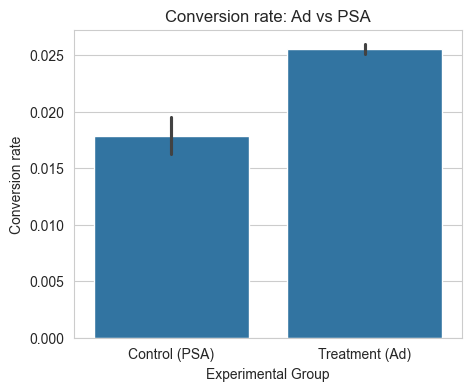

In [32]:
plt.figure(figsize=(5,4))

order = ["psa", "ad"]
ax = sns.barplot(
    data=df,
    x="test_group",
    y="converted_num",
    errorbar=("ci", 95),
    order=order
)

ax.set_ylabel("Conversion rate")
ax.set_xlabel("Experimental Group")
ax.set_title("Conversion rate: Ad vs PSA")

# set ticks + labels explicitly to avoid the warning
ax.set_xticks(range(len(order)))
ax.set_xticklabels(["Control (PSA)", "Treatment (Ad)"])

plt.show()

In [33]:
ad = df.loc[df.test_group=="ad", "converted_num"]
psa = df.loc[df.test_group=="psa", "converted_num"]

t, p = stats.ttest_ind(ad, psa, equal_var=True)
print(f"T test statistic: {t}\np-value: {p}")

T test statistic: 7.37040597428566
p-value: 1.7033052627831264e-13


AI use: We used a lot of genAI to get started and then customized as we saw fit. We have done this type of work before, so generally understood how to do it, but we had limited time during class and just used AI to speed up the process.